<a href="https://colab.research.google.com/github/ST10059601/APDS-Part-2-POE/blob/master/act_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark kaggle

In [10]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, count, desc, split, explode
import matplotlib.pyplot as plt
import findspark

In [11]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

In [12]:
findspark.init()
spark = SparkSession.builder.appName("Amazon-Spark-Analysis").getOrCreate()
spark

In [21]:
from pyspark.sql.functions import regexp_extract, regexp_replace, split, size, when

df_raw = spark.read.text("train.ft.txt.bz2")

df = df_raw.withColumn("star_rating", regexp_extract("value", r"^__label__(\d+)", 1).cast("int"))

df = df.withColumn("review_body",regexp_replace("value", r"^__label__\d+\s+", ""))

df = df.withColumn("star_rating", when(df.star_rating == 1, 1).when(df.star_rating == 2, 5))

df = df.drop("value")

df.show(5, truncate=False)


+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|star_rating|review_body                                                                                                                                                                                                         

In [22]:
print("Total reviews:", df.count())
df.groupBy("star_rating").count().show()


Total reviews: 3600000
+-----------+-------+
|star_rating|  count|
+-----------+-------+
|          1|1800000|
|          5|1800000|
+-----------+-------+



In [23]:
df.createOrReplaceTempView("reviews")


In [24]:
spark.sql("""
SELECT star_rating, COUNT(*) AS review_count
FROM reviews
GROUP BY star_rating
ORDER BY star_rating
""").show()


+-----------+------------+
|star_rating|review_count|
+-----------+------------+
|          1|     1800000|
|          5|     1800000|
+-----------+------------+



In [25]:

df = df.withColumn("review_length", size(split("review_body", " ")))


df = df.withColumn("is_positive", when(df.star_rating >= 4, 1).otherwise(0))

df.show(5, truncate=False)


+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+-----------+
|star_rating|review_body                                                                                                                                                                               

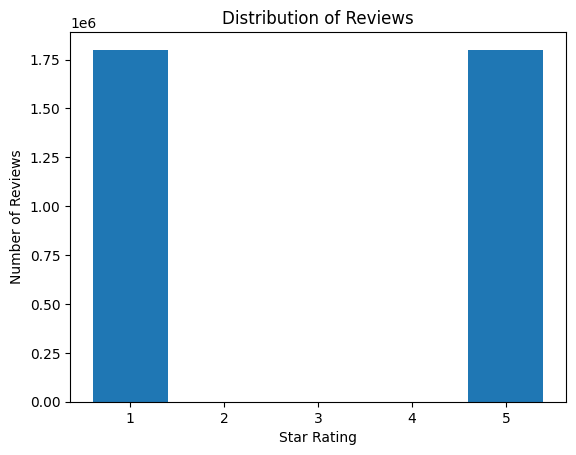

In [26]:
import matplotlib.pyplot as plt

# Convert to Pandas for plotting
pdf = df.groupBy("star_rating").count().toPandas()

plt.bar(pdf["star_rating"], pdf["count"])
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Reviews")
plt.show()
